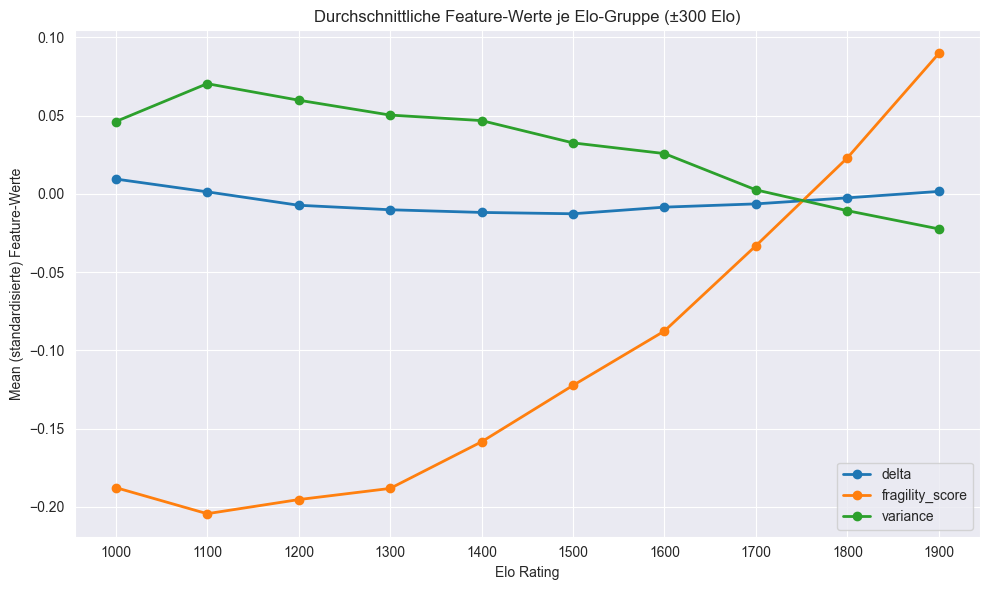

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# --- 1. Datensatz einlesen ---
PARQUET_PATH = "../data/score_dataset.parquet"
FEATURES = ["delta", "fragility_score", "variance"]
ELOS = list(range(1000, 2000, 100))
ELO_DEV = 300
MIN_SAMPLES_PER_GROUP = 15

df = pd.read_parquet(PARQUET_PATH)

# --- 2. (Optional) FEATURES standardisieren
# Wenn ihr die rohen Werte lieber skaliert als direkt zu mitteln, könnt ihr das hier einschalten.
# Falls ihr die Original-Skalen behalten möchtet, einfach diese Zeilen auskommentieren.
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[FEATURES] = scaler.fit_transform(df[FEATURES])
df = df_scaled

# --- 3. Berechnung der Mittelwerte pro ELO-Gruppe ---
# Wir legen ein DataFrame 'elo_stats' an, dessen Index die ELOS ist und Spalten die FEATURES:
elo_stats = pd.DataFrame(index=ELOS, columns=FEATURES, dtype=float)

for elo in ELOS:
    # Maske: alle Zeilen, deren played_by_elo in [elo - ELO_DEV, elo + ELO_DEV] liegt
    lower = elo - ELO_DEV
    upper = elo + ELO_DEV
    mask = df["played_by_elo"].between(lower, upper, inclusive="both")
    group = df.loc[mask, FEATURES]

    # Nur mitteln, falls genügend Samples vorhanden sind
    if len(group) >= MIN_SAMPLES_PER_GROUP:
        elo_stats.loc[elo, :] = group.mean().values
    else:
        # Bei zu wenigen Samples setzen wir NaN (diese ELO taucht später im Plot als Lücke auf)
        elo_stats.loc[elo, :] = np.nan

# (Optional) Zeilen entfernen, die komplett NaN sind:
elo_stats = elo_stats.dropna(how="all")

# --- 4. Plot der Mittelwerte für jedes Feature über die ELO-Stufen hinweg ---
plt.figure(figsize=(10, 6))

for feature in FEATURES:
    # Rohdaten (bspw. elo_stats[feature].values) ggf. glätten
    y = elo_stats[feature].values


    plt.plot(
        elo_stats.index,
        y,
        marker='o',
        linewidth=2,
        label=feature  # Falls ihr lieber sprechende Labels wollt, tauscht hier gegen ein dict um
    )

plt.xlabel("Elo Rating")
plt.ylabel("Mean (standardisierte) Feature-Werte")
plt.xticks(elo_stats.index)
plt.title("Durchschnittliche Feature-Werte je Elo-Gruppe (±{0} Elo)".format(ELO_DEV))
plt.legend()
plt.tight_layout()
plt.savefig("../images/elo_feature_means.svg")
plt.show()


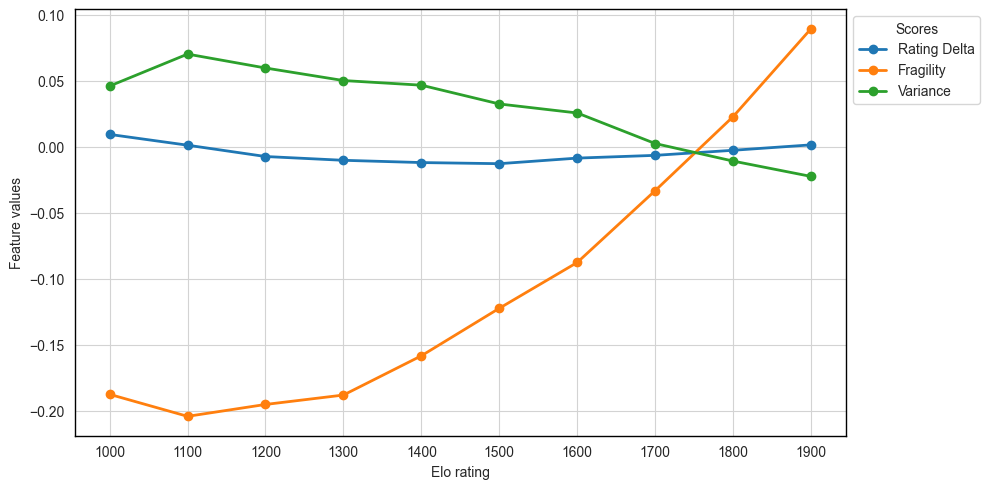

In [2]:
# Report he mean of each standardized feature, grouped by Elo band
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_facecolor("white")
feature_labels = {
    "fragility_score": "Fragility",
    "delta": "Rating Delta",
    "variance": "Variance"
}

for feature in FEATURES:
    y = elo_stats[feature].values
    plt.plot(elo_stats.index, y, marker='o', linewidth=2, label=feature_labels.get(feature, feature))

ax.set_axisbelow(True)
ax.grid(True, color="lightgray")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)
ax.set_xlabel("Elo rating")
ax.set_ylabel("Feature values")
ax.set_xticks(elo_stats.index)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    title="Scores",
    facecolor="white"
)
fig.tight_layout()
fig.savefig("../images/feature_means.pdf")
plt.show()

C:\Users\Philipp\AppData\Local\Temp\ipykernel_17076\467983932.py:73: UserWarning: Glyph 8208 (\N{HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Philipp\AppData\Local\Temp\ipykernel_17076\467983932.py:74: UserWarning: Glyph 8208 (\N{HYPHEN}) missing from font(s) Arial.
  plt.savefig("../images/elo_feature_means_group_norm.svg")
C:\Users\Philipp\Documents\Code\chess\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8208 (\N{HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


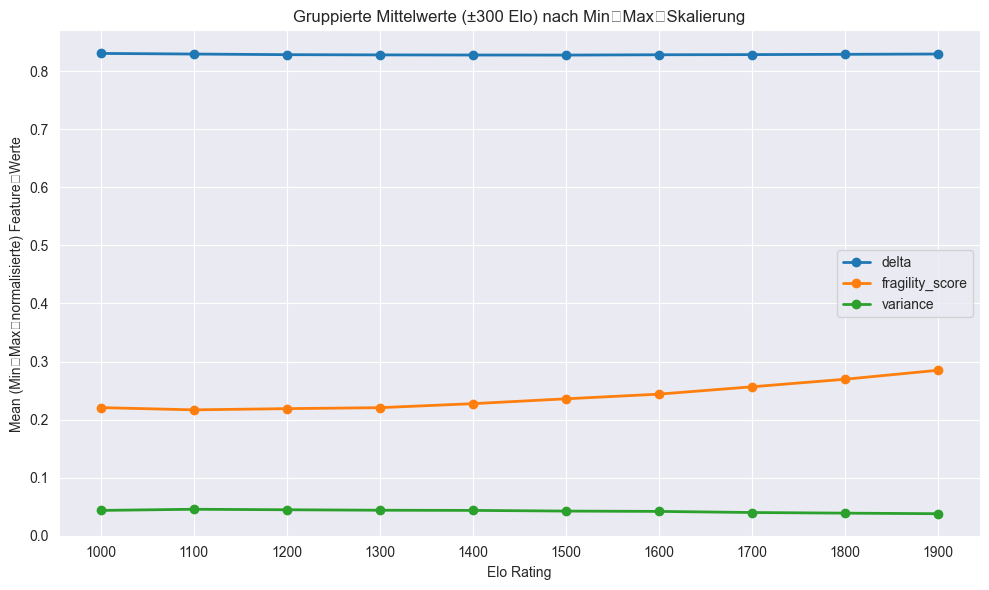

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Datensatz einlesen ---
PARQUET_PATH = "../data/score_dataset.parquet"
FEATURES = ["delta", "fragility_score", "variance"]
ELOS = list(range(1000, 2000, 100))
ELO_DEV = 300
MIN_SAMPLES_PER_GROUP = 15

df = pd.read_parquet(PARQUET_PATH)

# --- 2. Für jede Elo‐Gruppe: Min‐Max‐Skalierung auf die FEATURES anwenden ---
# Ergebnis‐DataFrame, in dem später die gruppierten Mittelwerte stehen
elo_stats = pd.DataFrame(index=ELOS, columns=FEATURES, dtype=float)

for elo in ELOS:
    # 2.1. Fenster‐Maske für das Intervall [elo - ELO_DEV, elo + ELO_DEV]
    lower = elo - ELO_DEV
    upper = elo + ELO_DEV
    mask = df["played_by_elo"].between(lower, upper, inclusive="both")
    group = df.loc[mask, FEATURES].copy()  # .copy(), damit Skalierung nicht ins Original schreibt

    # 2.2. Nur fortfahren, wenn genug Samples da sind
    if len(group) < MIN_SAMPLES_PER_GROUP:
        # Zu wenige Samples: schreiben wir NaN, um später Lücken im Plot zu haben
        elo_stats.loc[elo, :] = np.nan
        continue

    # 2.3. Min‐Max‐Skalierung **innerhalb** dieser Gruppe
    #       new = (old - min) / (max - min)
    # Achtung: Wenn max == min für ein Feature, setzen wir alle Werte auf 0.5
    group_min = group.min()
    group_max = group.max()
    range_ = group_max - group_min

    # Lege ein leeres DataFrame an, um die normalisierten Werte zu speichern
    group_norm = pd.DataFrame(index=group.index, columns=FEATURES, dtype=float)

    for feat in FEATURES:
        if range_[feat] == 0:
            # Falls alle Werte identisch, setzen wir sie auf 0.5
            group_norm[feat] = 0.5
        else:
            group_norm[feat] = (group[feat] - group_min[feat]) / range_[feat]

    # 2.4. Nun den Mittelwert der normalisierten Features in elo_stats eintragen
    elo_stats.loc[elo, :] = group_norm.mean().values

# 2.5. (Optional) Entferne Elo‐Stufen, bei denen alle Mittelwerte NaN sind
elo_stats = elo_stats.dropna(how="all")


# --- 3. Plot der gruppierten, min‐max‐normalisierten Mittelwerte ---
plt.figure(figsize=(10, 6))

for feature in FEATURES:
    y = elo_stats[feature].values
    plt.plot(
        elo_stats.index,
        y,
        marker="o",
        linewidth=2,
        label=feature  # Falls du lieber Abkürzungen ersetzen willst, kannst du hier ein Dict verwenden
    )

plt.xlabel("Elo Rating")
plt.ylabel("Mean (Min‐Max‐normalisierte) Feature‐Werte")
plt.xticks(elo_stats.index)
plt.title(f"Gruppierte Mittelwerte (±{ELO_DEV} Elo) nach Min‐Max‐Skalierung")
plt.legend()
plt.tight_layout()
plt.savefig("../images/elo_feature_means_group_norm.svg")
plt.show()
